# Time-varying cointegration and the Kalman filter — is the dynamic hedge spurious?

**Paper:** Eroğlu, Miller & Yiğit (2021), *Time-varying cointegration and the Kalman filter*, Econometric Reviews. [doi:10.1080/07474938.2020.1861776](https://doi.org/10.1080/07474938.2020.1861776)

**Why it matters for this repo.** `pairs.models.kalman` fits the time-varying hedge

$$y_t = \alpha_t + \beta_t x_t + \varepsilon_t,\qquad (\beta_t,\alpha_t)\ \text{random walks},$$

and the pipeline then runs ADF/KPSS on the Kalman residual. The paper's warning is precise: when $y_t$ and $x_t$ are **independent I(1) series**, a Kalman filter with a time-varying coefficient *forces the residual to be I(0)* and pushes the unit root into $\beta_t$. The filter cannot tell a spurious regression from a genuinely time-varying cointegrating relation, and stationarity of the Kalman residual is **not** evidence of cointegration.

**The remedy.** Move the measurement error into the state vector and let it be persistent:

$$
\begin{aligned}
y_t &= \alpha + x_t\beta_t + w_t \\
\beta_t &= \mu + T\beta_{t-1} + \eta_t,\qquad \eta_t\sim N(0,\sigma_\eta^2)\\
w_t &= \theta w_{t-1} + \varepsilon_t,\qquad\ \ \varepsilon_t\sim N(0,\sigma_\varepsilon^2)
\end{aligned}
$$

(the paper's model with $p=1$ regressor and $k=0$ extra lags). The persistence $\theta$ now carries the answer:

| $\theta$ | $\sigma_\eta$ | verdict |
|---|---|---|
| $=1$ | any | **no cointegration** — the "relationship" is spurious |
| $<1$ | $=0$ | **fixed-coefficient cointegration** (a static hedge is enough) |
| $<1$ | $>0$ | **time-varying cointegration** (a dynamic hedge is warranted) |

Inference is by bootstrap $t$-tests on $\theta=1$ and $\sigma_\eta=0$ (Section 3 of the paper).

**What this notebook does**

1. Reproduces the trap with the package's own Kalman hedge on independent random walks, and measures how often the pipeline's residual test is fooled.
2. Implements the paper's model with `statsmodels`' state-space machinery and shows it separates the three regimes.
3. Implements the paper's bootstrap $t$-tests and decision rule.
4. Replicates a slice of the paper's Monte Carlo (Table 1: size and power).
5. Applies the tests to real pairs from the package universe and compares with Engle–Granger and with the pipeline's Kalman-residual verdict.

## 0. Setup

In [1]:
from pathlib import Path
import sys, time, warnings

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")       # statsmodels optimizer / KPSS interpolation chatter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.tsa.stattools import coint
from scipy.special import expit
from joblib import Parallel, delayed

import pairs
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.stats.stationarity import test_spread_stationarity as stationarity_test, estimate_halflife

N_JOBS = -1                             # joblib workers for the bootstrap / Monte Carlo sections
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
print("pairs", pairs.__version__, "| statsmodels", sm.__version__)

pairs 0.1.0 | statsmodels 0.14.6


## 1. The trap: the package's Kalman hedge on two unrelated random walks

Two independent random walks have no cointegrating relation. A static regression of one on the other is the textbook spurious regression: the OLS residual is I(1) and Engle–Granger cannot reject a unit root. Feed the same two series to `pairs.models.kalman` (state $[\beta_t,\alpha_t]$ as random walks, `mode="filter"` so there is no look-ahead) with the package defaults, at price-like levels (started at 100, unit-variance steps), and look at what the filter does with the nonstationarity.

Kalman residual  ADF p=0.014   KPSS p=0.077   verdict=stationary       half-life=2.6
OLS residual     ADF p=0.354   KPSS p=0.100   verdict=inconclusive     half-life=11.2
Engle–Granger on the levels: p = 0.597  (correctly finds no cointegration)


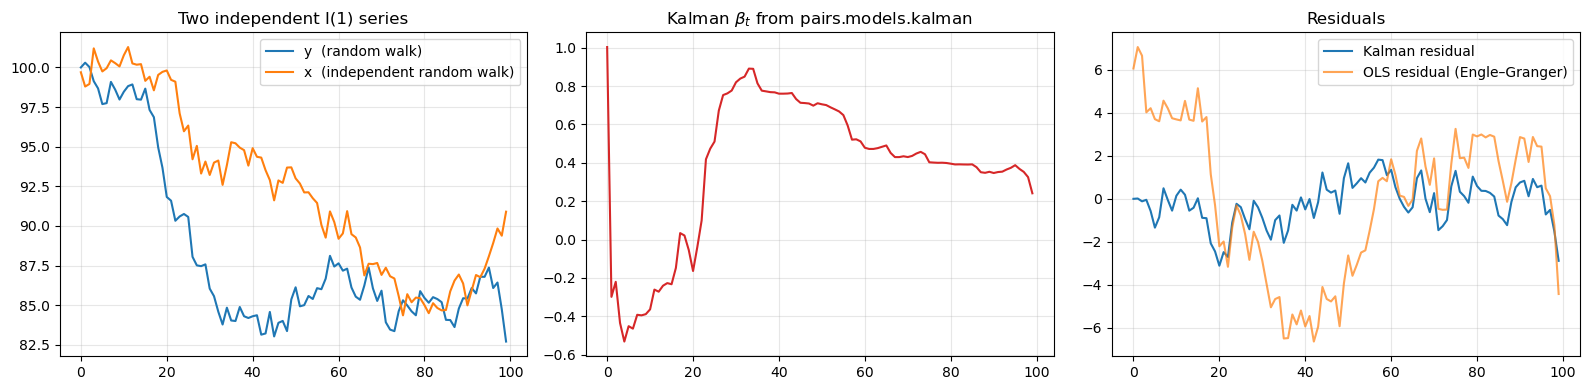

In [2]:
def independent_random_walks(n: int, seed: int, level: float = 100.0) -> pd.DataFrame:
    # Two independent random walks with unit-variance steps, started at `level`
    # (100 = price-like, as the package is used; 0 = the paper's simulation scale).
    rng = np.random.default_rng(seed)
    return pd.DataFrame({"P1": level + np.cumsum(rng.standard_normal(n)),
                         "P2": level + np.cumsum(rng.standard_normal(n))},
                        index=pd.RangeIndex(n, name="t"))

def repo_kalman(df: pd.DataFrame, **kw) -> pd.DataFrame:
    # The package's Kalman dynamic hedge (filtered states only, no smoothing look-ahead).
    _, _, states, _ = _kalman_dynamic_hedge("Y", "X", df, mode="filter", **kw)
    return states

def ols_resid(df: pd.DataFrame) -> pd.Series:
    # Engle-Granger step 1: static OLS of P1 on P2.
    X = sm.add_constant(df["P2"].to_numpy())
    return pd.Series(sm.OLS(df["P1"].to_numpy(), X).fit().resid, index=df.index)

def stationarity_verdict(e: pd.Series) -> dict:
    # The package's ADF + KPSS verdict, with KPSS look-up-table warnings silenced.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return stationarity_test(e)

df_rw = independent_random_walks(100, seed=7)
st_rw = repo_kalman(df_rw)
e_ols = ols_resid(df_rw)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(df_rw["P1"], label="y  (random walk)")
axes[0].plot(df_rw["P2"], label="x  (independent random walk)")
axes[0].set_title("Two independent I(1) series"); axes[0].legend()
axes[1].plot(st_rw["beta"], color="C3")
axes[1].set_title(r"Kalman $\beta_t$ from pairs.models.kalman")
axes[2].plot(st_rw["resid"], label="Kalman residual")
axes[2].plot(e_ols, label="OLS residual (Engle–Granger)", alpha=0.7)
axes[2].set_title("Residuals"); axes[2].legend()
plt.tight_layout()

for name, e in [("Kalman residual", st_rw["resid"]), ("OLS residual", e_ols)]:
    r = stationarity_verdict(e)
    print(f"{name:16s} ADF p={r['adf_p']:.3f}   KPSS p={r['kpss_p']:.3f}   verdict={r['verdict']:14s}   half-life={estimate_halflife(e):.1f}")
print(f"Engle–Granger on the levels: p = {coint(df_rw['P1'], df_rw['P2'])[1]:.3f}  (correctly finds no cointegration)")

The OLS residual is a random walk, as it should be. The Kalman residual is small and mean-reverting — because $\beta_t$ has absorbed the wandering. The pipeline's stationarity verdict, applied to the Kalman residual, is fooled.

How often, and what does it depend on? The filter can only manufacture a stationary residual if $\beta_t$ is allowed to move. The package's transition variance `q` (default $10^{-5}$) sets the step size of $\beta_t$, but what matters for the fit is the step size *of the fitted line*, $q\,x_t^2$: at unit-scale levels (the paper's simulations) the default is stiff, at price-like levels ($x_t\approx100$) the same default lets the fitted line move by $\sqrt{10^{-5}}\times100\approx0.3$ per bar, the same order as the price change itself. Monte Carlo over independent random-walk pairs (one year of daily bars), varying both:

In [3]:
def _false_positive_rep(seed: int, level: float, q: float, n: int = 250) -> dict:
    warnings.filterwarnings("ignore")            # runs in a joblib worker process
    df = independent_random_walks(n, seed, level)
    r = stationarity_verdict(repo_kalman(df, q=q)["resid"])
    return {"start level": level, "q (transition var.)": q,
            "Kalman resid: ADF p<0.05": r["adf_p"] < 0.05,
            "Kalman resid: pipeline verdict 'stationary'": r["verdict"] == "stationary",
            "Engle–Granger p<0.05 (levels)": coint(df["P1"], df["P2"])[1] < 0.05}

M_FP = 200
grid = [(s, lv, q) for lv in [0.0, 100.0] for q in [1e-5, 1e-3, 1e-2, 1e-1] for s in range(M_FP)]
t0 = time.time()
fp = pd.DataFrame(Parallel(n_jobs=N_JOBS)(delayed(_false_positive_rep)(*g) for g in grid))
print(f"{len(fp)} independent random-walk pairs in {time.time() - t0:.0f}s")

false_pos = fp.groupby(["start level", "q (transition var.)"]).mean()
(false_pos.style.format("{:.0%}").background_gradient(cmap="Reds", vmin=0, vmax=1)
          .set_caption("Share of NON-cointegrated pairs declared stationary (q = 1e-5 is the package default)"))

1600 independent random-walk pairs in 5s


**Reading.** Engle–Granger on the levels keeps roughly its nominal false-positive rate whatever the scale, which is why the package's dual-gate screen on price *levels* is the right first gate. The Kalman-residual test is a different animal: at the paper's unit scale the package default is stiff enough that "only" a quarter of unrelated pairs pass, but as soon as the filter can move $\beta_t$ — larger `q`, or simply price-like levels with the default `q` — essentially every unrelated pair gets a "stationary" spread. Anything downstream of the Kalman fit (half-life, residual sigma, the composite score) inherits this: they describe the filter's fit, not the existence of a long-run relation. Section 5 shows the same thing on real prices.

## 2. The paper's model: put the error in the state and estimate its persistence

The class below implements equations (1)–(3) of the paper for one regressor and $k=0$ with `statsmodels`' `MLEModel`:

* state $\xi_t = (\beta_t, w_t)'$, transition $\mathrm{diag}(T,\theta)$, state intercept $(\mu, 0)'$, state covariance $\mathrm{diag}(\sigma_\eta^2, \sigma_\varepsilon^2)$;
* observation $y_t = \alpha + [x_t\ \ 1]\,\xi_t$ with **no** separate measurement noise (it lives in $w_t$);
* $\beta_0$ diffuse (large variance), $w_0 = 0$ exactly, as in the paper (this is what identifies $\alpha$);
* $T\in(0,1)$ via a logistic transform; $\theta$, $\sigma_\eta$, $\sigma_\varepsilon$ unconstrained (variances enter squared, so $\sigma_\eta=0$ is attainable and the $\sigma_\eta$ test is a test on the boundary, exactly the paper's setting).

Maximum likelihood is run by `fit()` with standard errors from the inverse Hessian (`cov_type="oim"`, the paper's footnote 5; `statsmodels` defaults to the outer product of gradients, which gave slightly less power in a side check); restricted fits for the bootstrap use `fix_params`.

In [4]:
class TVCointModel(MLEModel):
    '''Eroğlu–Miller–Yiğit TVSSM, p = 1 regressor, k = 0.
       y_t = alpha + x_t beta_t + w_t ;  beta_t = mu + T beta_{t-1} + eta_t ;  w_t = theta w_{t-1} + eps_t'''
    param_names = ["alpha", "mu", "T", "theta", "sigma_eta", "sigma_eps"]

    def __init__(self, y, x, beta0_var: float = 1e6):
        y = np.asarray(y, float); x = np.asarray(x, float)
        super().__init__(y, k_states=2, k_posdef=2, initialization="known",
                         initial_state=np.zeros(2), initial_state_cov=np.diag([beta0_var, 0.0]))
        design = np.zeros((1, 2, len(y)))
        design[0, 0, :] = x; design[0, 1, :] = 1.0          # time-varying design row [x_t, 1]
        self.ssm["design"] = design
        self.ssm["selection"] = np.eye(2)
        self.ssm["obs_cov"] = np.zeros((1, 1))
        ols = sm.OLS(y, sm.add_constant(x)).fit()           # starting values from the static regression
        self._start = np.array([ols.params[0], 0.1 * ols.params[1], 0.9, 0.9,
                                0.05 * abs(ols.params[1]) + 1e-3, np.std(ols.resid)])

    @property
    def start_params(self):
        return self._start

    def transform_params(self, u):
        c = u.copy(); c[2] = expit(u[2]); return c                        # T in (0, 1)

    def untransform_params(self, c):
        u = c.copy(); T = np.clip(c[2], 1e-6, 1 - 1e-6); u[2] = np.log(T / (1 - T)); return u

    def update(self, params, **kw):
        params = super().update(params, **kw)
        alpha, mu, T, theta, s_eta, s_eps = params
        self.ssm["obs_intercept"] = np.array([[alpha]])
        self.ssm["state_intercept"] = np.array([[mu], [0.0]])
        self.ssm["transition"] = np.array([[T, 0.0], [0.0, theta]])
        self.ssm["state_cov"] = np.diag([s_eta ** 2, s_eps ** 2])


def fit_tvssm(y, x, fixed: dict | None = None, maxiter: int = 500):
    '''ML fit; `fixed` (e.g. {"theta": 1.0}) imposes a restriction for the bootstrap.'''
    model = TVCointModel(y, x)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")            # optimizer chatter (joblib resets the kernel's filters)
        if fixed:
            with model.fix_params(fixed):
                return model.fit(disp=False, maxiter=maxiter, cov_type="oim")
        return model.fit(disp=False, maxiter=maxiter, cov_type="oim")   # Hessian-based s.e., as in the paper


def t_theta(res) -> float:       # H0: theta = 1, left-sided
    return (res.params[3] - 1.0) / res.bse[3]

def t_sigma(res) -> float:       # H0: sigma_eta = 0, right-sided (sigma_eta enters squared, sign is irrelevant)
    return abs(res.params[4]) / res.bse[4]

def summarize_fit(res) -> pd.Series:
    p = dict(zip(TVCointModel.param_names, res.params)); se = dict(zip(TVCointModel.param_names, res.bse))
    return pd.Series({"theta": p["theta"], "se(theta)": se["theta"], "t(theta=1)": t_theta(res),
                      "|sigma_eta|": abs(p["sigma_eta"]), "se(sigma_eta)": se["sigma_eta"], "t(sigma_eta=0)": t_sigma(res),
                      "T": p["T"], "mu": p["mu"], "sigma_eps": abs(p["sigma_eps"]),
                      "converged": bool(res.mle_retvals.get("converged", False))})


def simulate_tvssm(n: int, theta: float, sigma_eta: float, *, T: float = 0.7,
                   alpha: float = 0.0, sigma_eps: float = 1.0, seed: int = 0) -> pd.DataFrame:
    '''DGP of Section 4 of the paper: x_t a random walk with unit-variance steps, sigma_eps = 1,
       T = 0.7, mu = 1/(1 - T), beta_0 at its unconditional mean mu/(1 - T) (≈ 11), w_0 = 0.'''
    rng = np.random.default_rng(seed)
    x = np.cumsum(rng.standard_normal(n))
    mu = 1.0 / (1.0 - T)
    beta = np.empty(n); w = np.empty(n); b, wv = mu / (1.0 - T), 0.0
    for t in range(n):
        b = mu + T * b + sigma_eta * rng.standard_normal()
        wv = theta * wv + sigma_eps * rng.standard_normal()
        beta[t], w[t] = b, wv
    return pd.DataFrame({"y": alpha + x * beta + w, "x": x, "beta_true": beta, "w_true": w})

### 2.1 The naive TVSSM reproduces the trap by maximum likelihood (paper §2.1)

Fixing $\theta=0$ gives the paper's *naive* model — white measurement error and a time-varying coefficient — estimated by ML rather than with the package's fixed noise parameters. The paper reports $\hat T = 0.92$ and $\hat\sigma_\eta = 0.10$ on two independent random walks (at unit scale, $N=100$): instead of finding $\beta_t\equiv 0$, the filter makes $\beta_t$ nearly a random walk and fits the two unrelated series closely (their Figure 1). Same experiment here:

T              0.874
|sigma_eta|    0.161
sigma_eps      1.856


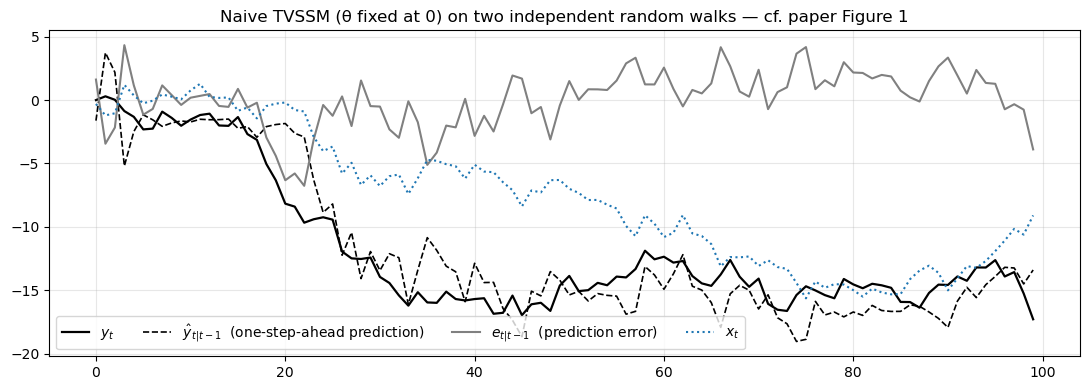

In [5]:
df_rw0 = independent_random_walks(100, seed=7, level=0.0)      # the paper's scale
res_naive = fit_tvssm(df_rw0["P1"], df_rw0["P2"], fixed={"theta": 0.0})
print(summarize_fit(res_naive)[["T", "|sigma_eta|", "sigma_eps"]].round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_rw0["P1"].values, "k", lw=1.6, label=r"$y_t$")
ax.plot(res_naive.fittedvalues, "k--", lw=1.2, label=r"$\hat y_{t|t-1}$  (one-step-ahead prediction)")
ax.plot(res_naive.resid, color="gray", label=r"$e_{t|t-1}$  (prediction error)")
ax.plot(df_rw0["P2"].values, ":", color="C0", label=r"$x_t$")
ax.set_title("Naive TVSSM (θ fixed at 0) on two independent random walks — cf. paper Figure 1"); ax.legend(ncol=4)
plt.tight_layout()

### 2.2 Adding the persistent error state separates the three regimes

Simulate the three cases of the paper's Section 4 DGP ($N=100$) and fit the full model. Look at $\hat\theta$ and $\hat\sigma_\eta$.

In [6]:
CASES = {
    "no cointegration      (θ=1.0, σ_η=0.0)": dict(theta=1.0, sigma_eta=0.0),
    "fixed cointegration   (θ=0.8, σ_η=0.0)": dict(theta=0.8, sigma_eta=0.0),
    "time-varying coint.   (θ=0.8, σ_η=0.3)": dict(theta=0.8, sigma_eta=0.3),
}
sims, fits = {}, {}
for name, kw in CASES.items():
    sims[name] = simulate_tvssm(100, seed=11, **kw)
    fits[name] = fit_tvssm(sims[name]["y"], sims[name]["x"])
est = pd.DataFrame({k: summarize_fit(v) for k, v in fits.items()}).T
est[["theta", "se(theta)", "t(theta=1)", "|sigma_eta|", "se(sigma_eta)", "t(sigma_eta=0)", "T", "sigma_eps", "converged"]]

,theta,se(theta),t(theta=1),|sigma_eta|,se(sigma_eta),t(sigma_eta=0),T,sigma_eps,converged
"no cointegration (θ=1.0, σ_η=0.0)",0.938541,0.038008,-1.616993,0.06611,0.100964,0.654785,0.682576,0.89158,True
"fixed cointegration (θ=0.8, σ_η=0.0)",0.619663,0.091156,-4.172398,0.000697,0.642444,0.001085,0.985092,0.908691,True
"time-varying coint. (θ=0.8, σ_η=0.3)",0.579652,0.150538,-2.792299,0.341918,0.058386,5.856133,0.677165,0.806806,True


Note how uninformative the standard error on $\hat\sigma_\eta$ is when the truth is $\sigma_\eta=0$: the estimate sits at the boundary and the likelihood is flat in that direction, so the $t$-statistic is essentially zero however the curvature is computed (the paper discusses this Hessian degeneracy in §3.4). It is one reason the paper bootstraps rather than relying on asymptotic $t$-statistics. In the fixed-coefficient case $T$ is not identified either ($\beta_t$ is constant whatever $T$ is), so ignore $\hat T$ there.

The filtered states track the truth in the time-varying case:

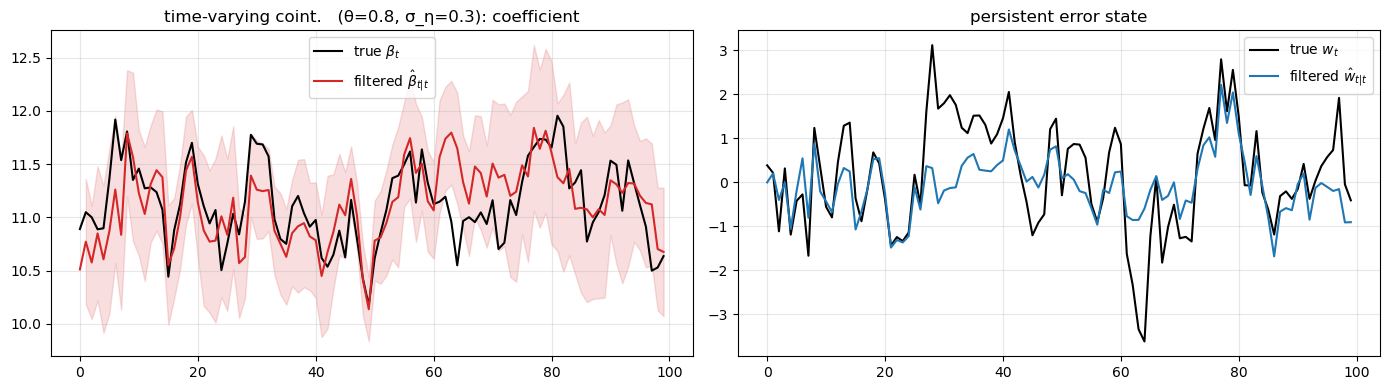

In [7]:
name = list(CASES)[2]; d, r = sims[name], fits[name]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(d["beta_true"], "k", label=r"true $\beta_t$")
axes[0].plot(r.filtered_state[0], "C3", label=r"filtered $\hat\beta_{t|t}$")
sd = np.sqrt(r.filtered_state_cov[0, 0])
axes[0].fill_between(range(len(d)), r.filtered_state[0] - 2 * sd, r.filtered_state[0] + 2 * sd, color="C3", alpha=0.15)
axes[0].set_title(name.strip() + ": coefficient"); axes[0].legend()
axes[1].plot(d["w_true"], "k", label=r"true $w_t$")
axes[1].plot(r.filtered_state[1], "C0", label=r"filtered $\hat w_{t|t}$")
axes[1].set_title("persistent error state"); axes[1].legend()
plt.tight_layout()

## 3. Inference: the paper's bootstrap $t$-tests and decision rule

Asymptotics are intractable here (the conditional variances never reach a steady state because $x_t$ is I(1); paper Appendix B.3), so the paper uses a **semi-parametric bootstrap that resamples the model innovations of the restricted model** (Section 3.1):

1. Fit the unrestricted model → test statistic $\hat\tau$.
2. Fit the restricted model ($\theta=1$, or $\sigma_\eta=0$) → $\hat\Psi_R$ and the predicted states $\beta_{R,t|t-1},\ w_{R,t|t-1}$.
3. Innovations $\hat\varepsilon_{R,t} = w_{R,t|t-1} - \theta_R\, w_{R,t-1|t-2}$ (for $\theta_R=1$ this is $\Delta w_{R,t|t-1}$), demeaned.
4. Resample with replacement, rebuild $w_t^{(b)}$ by the restricted recursion and $y_t^{(b)} = \hat\alpha_R + x_t\beta_{R,t|t-1} + w_t^{(b)}$. Note $\beta_{R,t|t-1}$ is held fixed across draws — the paper's second caveat.
5. Refit the unrestricted model on $(y^{(b)}, x)$, collect $\tau^{(b)}$; repeat $B$ times.

Reject $\theta=1$ if $\hat\tau_\theta$ is below the bootstrap 5% quantile (left tail); reject $\sigma_\eta=0$ if $\hat\tau_\sigma$ exceeds the 95% quantile (right tail). The paper uses $B=999$; $B=199$ below keeps the notebook quick.

In [8]:
def _refit_stat(y_b, x, stat):
    warnings.filterwarnings("ignore")            # runs in a joblib worker process
    try:
        return stat(fit_tvssm(y_b, x))
    except Exception:
        return np.nan

def bootstrap_test(y, x, null: dict, B: int = 199, seed: int = 0, n_jobs: int = N_JOBS) -> dict:
    '''Paper Section 3.1. null = {"theta": 1.0} (left-tailed) or {"sigma_eta": 0.0} (right-tailed).'''
    y = np.asarray(y, float); x = np.asarray(x, float); n = len(y)
    key = next(iter(null)); left_tail = key == "theta"
    stat = t_theta if left_tail else t_sigma

    res_U = fit_tvssm(y, x)
    res_R = fit_tvssm(y, x, fixed=null)
    tau = stat(res_U)

    alpha_R, theta_R = res_R.params[0], res_R.params[3]
    beta_pred, w_pred = res_R.predicted_state[0, :n], res_R.predicted_state[1, :n]   # t|t-1, t = 1..n
    eps = w_pred[1:] - theta_R * w_pred[:-1]
    eps = eps - eps.mean()

    rng = np.random.default_rng(seed)
    ys = []
    for _ in range(B):
        e_b = rng.choice(eps, size=n, replace=True)
        w_b = np.empty(n); wv = 0.0
        for t in range(n):
            wv = theta_R * wv + e_b[t]; w_b[t] = wv
        ys.append(alpha_R + x * beta_pred + w_b)
    boot = np.asarray(Parallel(n_jobs=n_jobs)(delayed(_refit_stat)(y_b, x, stat) for y_b in ys), float)
    boot = boot[np.isfinite(boot)]

    if boot.size == 0 or not np.isfinite(tau):
        p, crit = np.nan, np.nan               # undecidable (s.e. failed) — never counts as a rejection
    elif left_tail:
        p, crit = (boot <= tau).mean(), np.quantile(boot, 0.05)
    else:
        p, crit = (boot >= tau).mean(), np.quantile(boot, 0.95)
    return {"stat": tau, "p_value": p, "crit_5pct": crit, "boot": boot, "res_U": res_U, "res_R": res_R}


def classify(y, x, B: int = 199, seed: int = 0, level: float = 0.05) -> dict:
    '''Decision rule of the paper's Section 4.2 decision tables.'''
    th = bootstrap_test(y, x, {"theta": 1.0}, B=B, seed=seed)
    sg = bootstrap_test(y, x, {"sigma_eta": 0.0}, B=B, seed=seed + 1)
    reject_theta = np.isfinite(th["p_value"]) and th["p_value"] < level
    reject_sigma = np.isfinite(sg["p_value"]) and sg["p_value"] < level
    if not np.isfinite(th["p_value"]):
        verdict = "undecided (theta test failed)"
    elif not reject_theta:
        verdict = "no cointegration"
    elif reject_sigma:
        verdict = "time-varying cointegration"
    else:
        verdict = "fixed cointegration"
    p = dict(zip(TVCointModel.param_names, th["res_U"].params))
    return {"theta_hat": p["theta"], "t_theta": th["stat"], "p_theta": th["p_value"],
            "sigma_eta_hat": abs(p["sigma_eta"]), "t_sigma": sg["stat"], "p_sigma": sg["p_value"],
            "verdict": verdict}

In [9]:
t0 = time.time()
rows = {name: classify(d["y"], d["x"], B=199) for name, d in sims.items()}
print(f"3 pairs × 2 bootstrap tests × 199 replications in {time.time() - t0:.0f}s")
pd.DataFrame(rows).T

3 pairs × 2 bootstrap tests × 199 replications in 13s


,theta_hat,t_theta,p_theta,sigma_eta_hat,t_sigma,p_sigma,verdict
"no cointegration (θ=1.0, σ_η=0.0)",0.938541,-1.616993,0.120603,0.06611,0.654785,0.226131,no cointegration
"fixed cointegration (θ=0.8, σ_η=0.0)",0.619663,-4.172398,0.0,0.000697,0.001085,0.190955,fixed cointegration
"time-varying coint. (θ=0.8, σ_η=0.3)",0.579652,-2.792299,0.0,0.341918,5.856133,0.01005,time-varying cointegration


All three simulated regimes are classified correctly. Compare the bootstrap distribution of $t_\theta$ with the asymptotic $N(0,1)$ it is often assumed to follow:

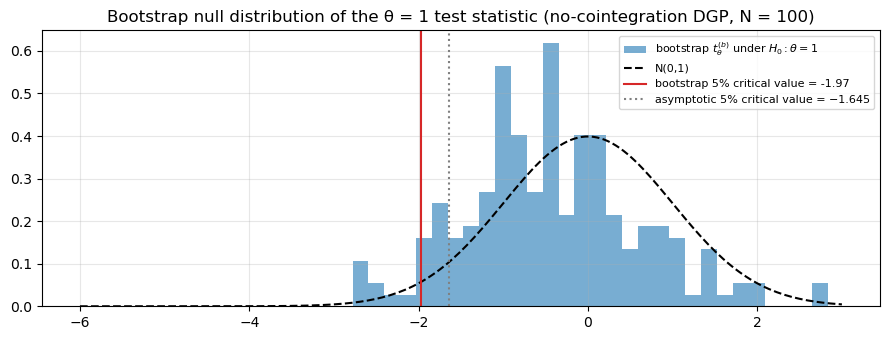

In [10]:
bt = bootstrap_test(sims[list(CASES)[0]]["y"], sims[list(CASES)[0]]["x"], {"theta": 1.0}, B=199)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(bt["boot"], bins=30, density=True, alpha=0.6, label=r"bootstrap $t_\theta^{(b)}$ under $H_0:\theta=1$")
grid = np.linspace(-6, 3, 200); ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "k--", label="N(0,1)")
ax.axvline(bt["crit_5pct"], color="C3", label=f"bootstrap 5% critical value = {bt['crit_5pct']:.2f}")
ax.axvline(-1.645, color="gray", ls=":", label="asymptotic 5% critical value = −1.645")
ax.set_title("Bootstrap null distribution of the θ = 1 test statistic (no-cointegration DGP, N = 100)"); ax.legend(fontsize=8)
plt.tight_layout()

## 4. Monte Carlo: size and power (a slice of the paper's Table 1)

The paper's Table 1 reports rejection frequencies at nominal 5% for $N=100$ over a grid of $\theta_0$ and $\sigma_{0,\eta}$, using the bootstrap at every replication (via the fast double bootstrap). Bootstrapping inside a Monte Carlo is too slow for a notebook, so this section does two cheaper things with $M=200$ replications per cell:

* rejection rates using the **asymptotic** critical values ($\pm1.645$) — showing how far off they are;
* **size-adjusted** rates, using the Monte Carlo 5% quantile of the statistic under the null in the same column as the critical value — which is what a well-behaved bootstrap approximates.

The paper's own numbers are shown alongside for reference.

In [11]:
def _mc_rep(theta0, sigma_eta0, seed, n=100):
    warnings.filterwarnings("ignore")            # runs in a joblib worker process
    d = simulate_tvssm(n, theta0, sigma_eta0, seed=seed)
    try:
        r = fit_tvssm(d["y"], d["x"])
        return theta0, sigma_eta0, t_theta(r), t_sigma(r), bool(r.mle_retvals.get("converged", False))
    except Exception:
        return theta0, sigma_eta0, np.nan, np.nan, False

M_MC = 200
THETAS, SIGMAS = [1.0, 0.95, 0.90, 0.80], [0.0, 0.1, 0.3, 0.5]
grid = [(th, sg, 1000 + s) for th in THETAS for sg in SIGMAS for s in range(M_MC)]
t0 = time.time()
mc = pd.DataFrame(Parallel(n_jobs=N_JOBS, batch_size=50)(delayed(_mc_rep)(*g) for g in grid),
                  columns=["theta0", "sigma_eta0", "t_theta", "t_sigma", "converged"])
print(f"{len(mc):,} fits in {time.time() - t0:.0f}s; converged {mc.converged.mean():.1%}; "
      f"non-finite statistics {mc[['t_theta','t_sigma']].isna().mean().round(3).to_dict()}")

3,200 fits in 22s; converged 99.3%; non-finite statistics {'t_theta': 0.0, 't_sigma': 0.0}


In [12]:
# Paper, Table 1 (N = 100, k = 0), columns sigma_eta in {0, 0.10, 0.30, 0.50}
paper_theta = pd.DataFrame([[.046,.054,.054,.054],[.519,.491,.379,.260],[.820,.763,.589,.383],[.979,.941,.743,.501]],
                           index=THETAS, columns=SIGMAS)
paper_sigma = pd.DataFrame([[.047,.490,.921,.971],[.052,.488,.899,.944],[.046,.457,.895,.945],[.049,.440,.874,.965]],
                           index=THETAS, columns=SIGMAS)

g = mc.dropna(subset=["t_theta"]).groupby(["theta0", "sigma_eta0"])
asym_theta = g["t_theta"].apply(lambda s: (s < -1.645).mean()).unstack()
crit_theta = mc[mc.theta0 == 1.0].groupby("sigma_eta0")["t_theta"].quantile(0.05)          # null: theta0 = 1, per column
adj_theta = g["t_theta"].apply(lambda s: (s < crit_theta[s.name[1]]).mean()).unstack()

g2 = mc.dropna(subset=["t_sigma"]).groupby(["theta0", "sigma_eta0"])
asym_sigma = g2["t_sigma"].apply(lambda s: (s > 1.645).mean()).unstack()
crit_sigma = mc[mc.sigma_eta0 == 0.0].groupby("theta0")["t_sigma"].quantile(0.95)          # null: sigma_eta0 = 0, per row
adj_sigma = g2["t_sigma"].apply(lambda s: (s > crit_sigma[s.name[0]]).mean()).unstack()

def show(df, title):
    df = df.copy(); df.index.name = "θ₀ \\ σ_η"
    return df.style.format("{:.3f}").background_gradient(cmap="Blues", vmin=0, vmax=1).set_caption(title)

display(show(asym_theta, "H0: θ = 1 — rejection rate, asymptotic −1.645 (first row = size)"))
display(show(adj_theta,  "H0: θ = 1 — rejection rate, size-adjusted critical value (first row = 5% by construction)"))
display(show(paper_theta, "H0: θ = 1 — paper Table 1, top panel (bootstrap, N = 100)"))

sigma_eta0,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
0.800000,0.980,0.965,0.780,0.653
0.900000,0.820,0.785,0.620,0.525
0.950000,0.545,0.545,0.430,0.355
1.000000,0.135,0.185,0.190,0.170


sigma_eta0,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
0.800000,0.765,0.675,0.415,0.322
0.900000,0.385,0.300,0.235,0.200
0.950000,0.170,0.165,0.150,0.140
1.000000,0.050,0.050,0.050,0.050


,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
1.000000,0.046,0.054,0.054,0.054
0.950000,0.519,0.491,0.379,0.260
0.900000,0.820,0.763,0.589,0.383
0.800000,0.979,0.941,0.743,0.501


In [13]:
display(show(asym_sigma, "H0: σ_η = 0 — rejection rate, asymptotic 1.645 (first column = size)"))
display(show(adj_sigma,  "H0: σ_η = 0 — rejection rate, size-adjusted (first column = 5% by construction)"))
display(show(paper_sigma, "H0: σ_η = 0 — paper Table 1, middle panel (bootstrap, N = 100)"))

sigma_eta0,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
0.800000,0.130,0.615,0.965,1.000
0.900000,0.145,0.640,0.980,0.995
0.950000,0.115,0.645,0.980,0.995
1.000000,0.125,0.690,0.980,0.995


sigma_eta0,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
0.800000,0.050,0.395,0.955,0.995
0.900000,0.050,0.455,0.970,0.995
0.950000,0.050,0.475,0.975,0.995
1.000000,0.050,0.490,0.975,0.995


,0.000000,0.100000,0.300000,0.500000
θ₀ \ σ_η,,,,
1.000000,0.047,0.490,0.921,0.971
0.950000,0.052,0.488,0.899,0.944
0.900000,0.046,0.457,0.895,0.945
0.800000,0.049,0.440,0.874,0.965


**Reading.** The qualitative pattern of the paper reproduces: power against $\theta<1$ rises as $\theta_0$ falls and *declines* as $\sigma_\eta$ grows (more coefficient variation makes a weak cointegrating relation harder to distinguish from a spurious one), while the $\sigma_\eta$ test is powerful and nearly unaffected by $\theta_0$. For the $\sigma_\eta$ test the size-adjusted rates land close to the paper's numbers.

For the $\theta$ test the levels do not match and it is worth being precise about how. The asymptotic critical value over-rejects under the null by a factor of three, which is the paper's case for the bootstrap. Once size is corrected, our power is roughly half the paper's for $\theta_0\ge0.9$ — and, curiously, our *uncorrected* rejection rates sit very close to the paper's bootstrap rates. Candidate explanations, none verified here: the paper's bootstrap conditions on the observed $x_t$ path and on the restricted estimates, whereas the size adjustment above uses the unconditional null quantile; the ML optimizer and the $\beta_0$ initialization may differ; and $M=200$ leaves a couple of percentage points of noise. Reproducing the paper's bootstrap inside the Monte Carlo (their fast double bootstrap) is the way to settle it.

## 5. Real pairs from the universe

Weekly log closes 2015–2025 for five economically plausible pairs and three "control" pairs with no economic link. For each pair we compare

* **Engle–Granger** on log levels (what the package's screen does, one of its two gates);
* the **package's Kalman-residual verdict** (Kalman on price levels with the package defaults, then ADF/KPSS) — the test Section 1 showed to be uninformative;
* the **paper's tests**: $\hat\theta$, bootstrap $p$-values for $\theta=1$ and $\sigma_\eta=0$, and the resulting verdict.

Prices are fetched through `pairs.load_prices("openbb", ...)` and cached under `notebooks/cache/` (gitignored).

In [14]:
TICKERS = ["XOM", "CVX", "KO", "PEP", "V", "MA", "HD", "LOW", "JPM", "GS", "AAPL", "NVDA", "MSFT", "XEL"]
PAIRS = [("XOM", "CVX"), ("KO", "PEP"), ("V", "MA"), ("HD", "LOW"), ("JPM", "GS"),   # plausible pairs
         ("AAPL", "XEL"), ("NVDA", "KO"), ("MSFT", "XOM")]                            # controls
PRICES = CACHE / "tv_coint_prices.parquet"

if PRICES.exists():
    close = pd.read_parquet(PRICES)
else:
    df_px, failed = pairs.load_prices("openbb", TICKERS, "2015-01-01", "2025-12-31", return_failed=True, show_progress=False)
    if failed: print("no data for:", failed)
    close = df_px["close"].unstack("ticker"); close.to_parquet(PRICES)

weekly = close.resample("W-FRI").last().dropna()
logw = np.log(weekly)
print(f"{weekly.shape[0]} weekly bars, {weekly.index.min().date()} → {weekly.index.max().date()}")

575 weekly bars, 2015-01-02 → 2026-01-02


In [15]:
def analyze_pair(a: str, b: str, B: int = 199) -> dict:
    y, x = logw[a], logw[b]
    eg_p = coint(y, x, trend="c")[1]
    st = repo_kalman(pd.DataFrame({"P1": weekly[a], "P2": weekly[b]}))     # package defaults on price levels
    kal = stationarity_verdict(st["resid"])
    out = {"pair": f"{a}/{b}", "EG p (levels)": eg_p, "Kalman-resid verdict": kal["verdict"], "Kalman-resid ADF p": kal["adf_p"]}
    out.update(classify(y.to_numpy(), x.to_numpy(), B=B))
    return out

t0 = time.time()
real = pd.DataFrame([analyze_pair(a, b) for a, b in PAIRS]).set_index("pair")
print(f"{len(PAIRS)} pairs in {time.time() - t0:.0f}s")
real.style.format({"EG p (levels)": "{:.3f}", "Kalman-resid ADF p": "{:.3f}", "theta_hat": "{:.3f}", "t_theta": "{:+.2f}",
                   "p_theta": "{:.3f}", "sigma_eta_hat": "{:.4f}", "t_sigma": "{:.2f}", "p_sigma": "{:.3f}"})

8 pairs in 112s


,EG p (levels),Kalman-resid verdict,Kalman-resid ADF p,theta_hat,t_theta,p_theta,sigma_eta_hat,t_sigma,p_sigma,verdict
pair,,,,,,,,,,
XOM/CVX,0.682,stationary,0.000,0.996,-0.94,0.317,0.0000,0.00,0.598,no cointegration
KO/PEP,0.671,stationary,0.000,0.991,-0.88,0.357,0.0021,1.31,0.281,no cointegration
V/MA,0.005,stationary,0.000,0.942,-3.59,0.000,0.0001,0.01,0.457,fixed cointegration
HD/LOW,0.109,stationary,0.000,0.998,-0.69,0.372,0.0003,0.07,0.528,no cointegration
JPM/GS,0.443,stationary,0.000,1.000,+0.20,0.719,0.0010,0.66,0.402,no cointegration
AAPL/XEL,0.631,stationary,0.000,1.003,+1.29,0.975,0.0048,1.67,0.161,no cointegration
NVDA/KO,0.017,inconclusive,0.000,1.002,+2.93,0.965,0.0000,0.00,0.829,no cointegration
MSFT/XOM,0.825,stationary,0.000,1.002,+2.09,0.980,0.0000,0.00,0.995,no cointegration


**Reading.** The package's Kalman-residual test returns "stationary" for seven of the eight pairs, controls included, with ADF $p$-values of 0.000 across the board — Section 1 on real prices. Engle–Granger and the paper's $\theta$ test agree on seven pairs: only V/MA is cointegrated over 2015–2025 at weekly frequency (EG $p=0.005$; $\hat\theta=0.94$, bootstrap $p<0.01$), and the textbook pairs XOM/CVX, KO/PEP, HD/LOW and JPM/GS are not, on either test, over a decade that contains large relative re-ratings for each of them. The one disagreement is NVDA/KO: Engle–Granger rejects at 5% ($p=0.017$) while $\hat\theta=1.00$ and the bootstrap does not; with NVDA's near-explosive trend the Engle–Granger rejection is the less credible of the two. For V/MA the $\sigma_\eta$ test does not reject ($p\approx0.46$): the cointegrating coefficient is *fixed*, so a static hedge is the right model and the dynamic one is adding noise.

The paper's filtered coefficient for V/MA — the one pair the tests call cointegrated, with a *fixed* coefficient — against the static OLS hedge ratio and the package's random-walk Kalman $\beta_t$ (all on log prices). Where $\sigma_\eta=0$ cannot be rejected, the wandering of the package's $\beta_t$ is estimation noise the strategy then trades on:

theta             0.9423
se(theta)         0.0161
t(theta=1)       -3.5866
|sigma_eta|       0.0001
se(sigma_eta)     0.0105
t(sigma_eta=0)    0.0067
T                 0.9009
mu                 0.082
sigma_eps         0.0129
converged              1


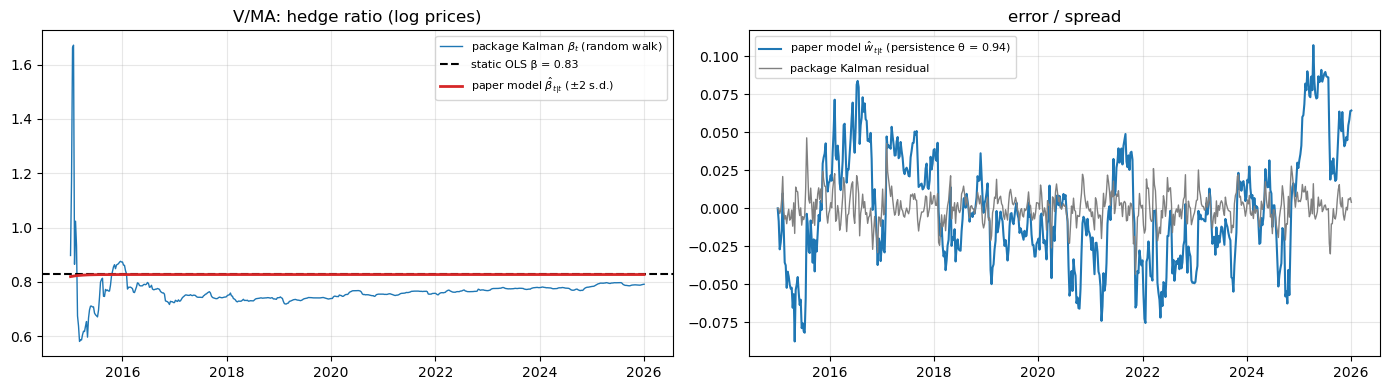

In [16]:
a, b = "V", "MA"
y, x = logw[a].to_numpy(), logw[b].to_numpy()
res = fit_tvssm(y, x)
beta_ols = sm.OLS(y, sm.add_constant(x)).fit().params[1]
st_log = repo_kalman(pd.DataFrame({"P1": logw[a], "P2": logw[b]}), r=float(np.var(y - beta_ols * x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sd = np.sqrt(res.filtered_state_cov[0, 0])
axes[0].plot(logw.index, st_log["beta"], "C0", lw=1, label=r"package Kalman $\beta_t$ (random walk)")
axes[0].axhline(beta_ols, color="k", ls="--", label=f"static OLS β = {beta_ols:.2f}")
axes[0].plot(logw.index, res.filtered_state[0], "C3", lw=2, label=r"paper model $\hat\beta_{t|t}$ (±2 s.d.)")
axes[0].fill_between(logw.index, res.filtered_state[0] - 2 * sd, res.filtered_state[0] + 2 * sd, color="C3", alpha=0.15)
axes[0].set_title(f"{a}/{b}: hedge ratio (log prices)"); axes[0].legend(fontsize=8)
axes[1].plot(logw.index, res.filtered_state[1], "C0", label=r"paper model $\hat w_{t|t}$ (persistence θ = %.2f)" % res.params[3])
axes[1].plot(logw.index, st_log["resid"], color="gray", lw=1, label="package Kalman residual")
axes[1].set_title("error / spread"); axes[1].legend(fontsize=8)
plt.tight_layout()
print(summarize_fit(res).round(4).to_string())

## 6. What this means for the pairs pipeline

1. **Never read cointegration off the Kalman residual.** With a time-varying coefficient the filter *manufactures* a stationary residual for any two I(1) series (Section 1). The `summarize_spread_stationarity_joblib` verdict, the half-life and `resid_sigma` computed on Kalman states describe the fit, not a long-run relation. The package's dual-gate screen on price levels (Engle–Granger + Johansen with BH correction) is the guard, and it must stay upstream of the Kalman step.

2. **The persistence of the error is the right diagnostic.** Embedding $w_t$ in the state and testing $\theta=1$ converts the Kalman machinery from a source of spurious relations into a test for them (Sections 2–3). It could serve as a third gate, or replace Engle–Granger for pairs where a fixed coefficient is implausible.

3. **Fixed vs time-varying is a testable choice, not an assumption.** The package assumes a random-walk $\beta_t$ ($T=1$, $\mu=0$) for every pair. The $\sigma_\eta$ test says whether the coefficient actually moves; where it does not reject, a static hedge has less estimation noise than the dynamic one, and where it does, the paper's estimate of $T$ is a more disciplined description than a pure random walk.

4. **Use the bootstrap.** The asymptotic $t$ critical values are badly sized for the $\theta$ test at practical sample sizes (Section 4) and the Hessian is degenerate at $\sigma_\eta=0$. The paper's innovation bootstrap is cheap enough here (a few seconds per pair on this machine) to run inside a screening loop.

**Limitations of this exploration.** One regressor and $k=0$ (the paper selects extra $\Delta w$ lags by BIC); Gaussian ML with a fixed diffuse prior on $\beta_0$; $B=199$ and $M=200$ instead of $999$ and $10{,}000$; a handful of hand-picked pairs at weekly frequency; and the size-adjusted Monte Carlo uses the oracle null quantile rather than a bootstrap at every replication.

## 7. Related literature

**The problem is older than the paper.**
* Canarella, Pollard & Lai (1990), [*Cointegration between exchange rates and relative prices: another view*](https://www.sciencedirect.com/science/article/abs/pii/001429219090002G), EER 34 — used time-varying coefficients to "rescue" PPP.
* Honohan (1993), *Cointegration and time-varying parameters: a comment*, EER 37(6) — the first statement of the trap: a time-varying cointegrating vector lets a lack of cointegration go unnoticed. Eroğlu, Miller & Yiğit formalize exactly this point.
* Kim (2006), *Time-varying parameter models with endogenous regressors*, Economics Letters 91 — the endogeneity side of TVP models with integrated regressors.

**Kalman filtering with integrated series — what asymptotics exist.**
* Chang, Miller & Park (2009), [*Extracting a common stochastic trend: theory with some applications*](https://www.sciencedirect.com/science/article/abs/pii/S0304407608002212), J. Econometrics 150 — consistency and mixed normality of Kalman ML with a single latent I(1) trend and *constant* loadings (earlier version: [*Using Kalman filter to extract and test for common stochastic trends*](https://economics.indiana.edu/documents/papers/using-kalman-filter-to-extract-and-test-for-common-stochastic-trends.pdf)). The present paper's Appendix B explains why this breaks down once the coefficient varies: the conditional variances never reach a steady state, hence the bootstrap.
* Tamayo, [*Common stochastic trends with the Kalman filter*](https://econweb.rutgers.edu/ctamayo/research/kf_monte.pdf) — Monte Carlo evidence on the Chang–Miller–Park estimator.
* Stoffer & Wall (1991), *Bootstrapping state-space models*, JASA 86 — the innovation bootstrap the paper adapts (and departs from: it resamples model innovations, not Kalman innovations, because the latter are badly size-distorted under nonstationarity).

**Testing parameter constancy in cointegrating regressions (the classical alternative to the $\sigma_\eta$ test).**
* Hansen (1992), [*Tests for parameter instability in regressions with I(1) processes*](https://users.ssc.wisc.edu/~behansen/papers/jbes_92.pdf), JBES 10(3) — LM tests ($L_c$, MeanF, SupF) whose random-walk-intercept alternative is precisely "no cointegration", so the same statistic doubles as a cointegration test with cointegration as the null.
* Quintos & Phillips (1993), [*Parameter constancy in cointegrating regressions*](https://link.springer.com/article/10.1007/BF01205416), Empirical Economics 18 — one-sided LM test of constant coefficients against random-walk coefficients; limit is a "stochastic bridge".
* Kuo (1998), [*Test for partial parameter instability in regressions with I(1) processes*](https://www.sciencedirect.com/science/article/abs/pii/S0304407698000050), J. Econometrics 86.
* Hansen & Johansen (1999), *Some tests for parameter constancy in cointegrated VAR models*, Econometrics J. 2 — the system (Johansen) counterpart; relevant because the package's second gate is a Johansen test.

**Smoothly / stochastically time-varying cointegration (the alternatives the paper positions itself against).**
* Park & Hahn (1999), *Cointegrating regressions with time varying coefficients*, Econometric Theory 15 — Fourier flexible-form coefficients.
* Bierens & Martins (2010), [*Time-varying cointegration*](https://www.cambridge.org/core/journals/econometric-theory/article/abs/timevarying-cointegration/BDE391A560CE91D3CAD53E66CA73DAAD), Econometric Theory 26 — Chebyshev-polynomial coefficients in a VECM with an LR test of constancy.
* Hansen (1992b), *Heteroskedastic cointegration*; Harris, McCabe & Leybourne (2002), *Stochastic cointegration*; McCabe, Leybourne & Harris (2006), [*A residual-based test for stochastic cointegration*](https://www.cambridge.org/core/journals/econometric-theory/article/abs/residualbased-test-for-stochastic-cointegration/B3193D38887FF6FBB886A64A1C1D134C) — the "stochastic freedom in the cointegrating vector" strand.
* A typical applied use of a time-varying cointegrating vector that the present paper's test would vet: [*Interest rate linkages: a Kalman filter approach to detecting structural change*](https://www.sciencedirect.com/science/article/abs/pii/S0264999303001032), Economic Modelling.

**Pairs-trading practice.** The random-walk-$\beta_t$ Kalman hedge used in this package is the standard recipe in the practitioner literature — e.g. [QuantStart](https://www.quantstart.com/articles/Dynamic-Hedge-Ratio-Between-ETF-Pairs-Using-the-Kalman-Filter/), [Palomar's *Portfolio Optimization* §15.6](https://portfoliooptimizationbook.com/book/15.6-kalman-pairs-trading.html), and Krauss (2017), [*Statistical arbitrage pairs trading strategies: review and outlook*](https://www.iwf.rw.fau.de/files/2016/03/09-2015.pdf), J. Econ. Surveys 31 — none of which tests whether the resulting stationary spread is an artifact of the filter. If part of the in-sample mean reversion is manufactured by the filter, the pairs that look best in sample should be the ones that break down most often out of sample; that is a testable prediction for the package's own walk-forward results.